# Fig. 2.13：大运动模型实验（motion EPE）

本 notebook 分为三段：

1. 从原始 ND2 数据裁剪参考体数据，并在 `motion radius=70`、`motion amplitude=20` 下生成仿真移动数据；
2. 分别运行 CoarseFlow 模型、从 identity 开始的直接迭代、以及从模型输出初始化的迭代；
3. 使用仿真的 ground-truth displacement 计算 motion EPE，并计算 raw intensity RMSE。

当前默认配置为：每个数据只使用一个原始 frame，并生成 10 个仿真结果；模型输入裁剪为 `1024 x 1024`，以保留更大的空间结构；若显存不足，可将 `CROP_SIZE_XY` 调回较小尺寸。

In [9]:
import csv
import json
import sys
import time
from pathlib import Path

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import torch

PROJECT_ROOT = Path("/home/cyf/wbi/Virginia/code_for_paper")
SRC_ROOT = PROJECT_ROOT / "wholistic_registration/src/wholistic_registration"
COARSEFLOW_ROOT = PROJECT_ROOT / "CoarseFlow"
FIG2_ROOT = PROJECT_ROOT / "Fig2"
EXP_ROOT = FIG2_ROOT / "2.13_large_motion_model"
SIM_ROOT = EXP_ROOT / "simulation"
OUTPUT_ROOT = EXP_ROOT / "model_outputs"
RESULT_ROOT = EXP_ROOT / "results"

for p in (PROJECT_ROOT, SRC_ROOT, COARSEFLOW_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from utils import calFlow3d_Wei_v1
from utils import calFlowCrossResolution as calflow
from utils import preprocess as prep
from utils.IO import readND2Frame
from utils.simulation import generateMotion_Biophysical
from CoarseFlow.training.inference import (
    CoarseFlowInferenceConfig,
    CoarseFlowPredictor,
    make_init_phase_xyz_from_z_init,
    percentile_normalize_01_np,
    run_getmotion_refine_from_phase,
    sample_ref_by_phase_np,
)

# ----------------------------
# Experiment configuration
# ----------------------------
CUDA_DEVICE = 1
DEVICE = f"cuda:{CUDA_DEVICE}" if torch.cuda.is_available() else "cpu"
USE_AMP = False

MODEL_PATH = COARSEFLOW_ROOT / "coarseflow_swin3d_v3_stage3_residual/best.pth"

# Confirmed from readMeta for the selected ND2 files.
DATASETS = {
    "F2013_15846": {
        "path": "/home/cyf/wbi/Virginia/raw_data/f2013/250705_f2013_ubi_gcamp7f_bactin_mcherry_6dpf_15846.nd2",
        "z_ratio": 3.0769230769230766,
        "frames": [0],
        "channel": 1,
        "z_crop": None,
        "n_moving_slices": 3,
    },
    "F338_003": {
        "path": "/home/cyf/wbi/Virginia/raw_data/f338/221124_f338_ubi_gCaMP7f_bactin_mCherry_CAAX_7dpf003.nd2",
        "z_ratio": 3.0769230769230766,
        "frames": [0],
        "channel": 1,
        "z_crop": 40,
        "n_moving_slices": 5,
    },
}

# Requested large-motion simulation parameters.
MOTION_RADIUS = 70.0   # !
MOTION_AMPLITUDE = 20.0 # !
NOISE_LEVEL = 0.0 # !
USE_INCOMPRESSIBILITY = True

# Ten simulations per original frame. Change to 20 if desired.
N_REPS_PER_FRAME = 30
BASE_SEED = 20260825

# Moving-slice count is configured per dataset: F2013=3, F338=5.
# Both use sparse step 8; this gives F2013 [1,9,17] and F338 [3,11,19,27,35].
DEFAULT_N_MOVING_SLICES = 3
SPARSE_Z_STEP = 8
CROP_SIZE_XY = (1024, 1024)  # set None to use the full XY frame
EVAL_MARGIN = 50           # exclude boundary pixels from EPE aggregation

# Refinement options. zRatio is completed per dataset as physical_zRatio * step.
WBI_R = 5
WBI_LAYER = 0
WBI_ITER = 10
WBI_SMOOTH_PENALTY_RAW = 0.03
WBI_MOV_RANGE = 10.0

FORCE_RERUN_SIMULATION = True
FORCE_RERUN_EVALUATION = True
SAVE_CLEAN_MOV = False

for d in (SIM_ROOT, OUTPUT_ROOT, RESULT_ROOT):
    d.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    torch.cuda.set_device(CUDA_DEVICE)
    cp.cuda.Device(CUDA_DEVICE).use()

print("Experiment root:", EXP_ROOT)
print("Model:", MODEL_PATH)
print("Device:", DEVICE)
for name, cfg in DATASETS.items():
    print(name, "zRatio=", cfg["z_ratio"], "frames=", cfg["frames"])

Experiment root: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model
Model: /home/cyf/wbi/Virginia/code_for_paper/CoarseFlow/coarseflow_swin3d_v3_stage3_residual/best.pth
Device: cuda:1
F2013_15846 zRatio= 3.0769230769230766 frames= [0]
F338_003 zRatio= 3.0769230769230766 frames= [0]


In [10]:
def to_numpy(x):
    if hasattr(x, "get"):
        x = x.get()
    return np.asarray(x)


def load_raw_frame(path, frame_idx, channel=1):
    arr = readND2Frame(str(path), int(frame_idx), channel=channel)
    arr = np.asarray(arr).squeeze()
    # Existing Fig. 2 code uses this conversion to obtain (X, Y, Z).
    if arr.ndim != 3:
        raise ValueError(f"Expected a 3D frame from {path}, got shape {arr.shape}")
    arr = arr.transpose(2, 1, 0).astype(np.float32, copy=False)
    return arr


def center_crop_xy(volume_xyz, crop_size_xy):
    volume_xyz = np.asarray(volume_xyz)
    if crop_size_xy is None:
        return volume_xyz
    crop_x, crop_y = map(int, crop_size_xy)
    nx, ny = volume_xyz.shape[:2]
    if crop_x > nx or crop_y > ny:
        raise ValueError(f"Crop {crop_size_xy} exceeds volume XY {(nx, ny)}")
    x0 = (nx - crop_x) // 2
    y0 = (ny - crop_y) // 2
    return volume_xyz[x0:x0 + crop_x, y0:y0 + crop_y, ...]


def center_crop_z(volume_xyz, n_z_keep):
    volume_xyz = np.asarray(volume_xyz)
    if n_z_keep is None:
        return volume_xyz, 0
    n_z_keep = int(n_z_keep)
    n_z = volume_xyz.shape[2]
    if n_z_keep > n_z:
        raise ValueError(f"z crop {n_z_keep} exceeds available z planes {n_z}")
    z0 = (n_z - n_z_keep) // 2
    return volume_xyz[:, :, z0:z0 + n_z_keep], z0


def make_z_init(n_z, sparse_step=SPARSE_Z_STEP, n_slices=DEFAULT_N_MOVING_SLICES):
    n_slices = int(n_slices)
    if n_slices % 2 != 1:
        raise ValueError("N_MOVING_SLICES must be odd for a symmetric z_init")
    half = n_slices // 2
    actual_step = int(sparse_step)
    z_center = (int(n_z) - 1) // 2
    offsets = np.arange(-half, half + 1, dtype=np.int32) * actual_step
    z_init = (z_center + offsets).astype(np.int32)
    if z_init.min() < 0 or z_init.max() >= n_z:
        raise ValueError(f"z_init={z_init.tolist()} is invalid for n_z={n_z}")
    return z_init, int(actual_step)


def build_gt_phase_kyx_xyz(motion_xyz, z_init, image_shape_yx):
    # motion_xyz is (X,Y,Z,3), with displacement channels ordered (x,y,z).
    gt_disp_xyk_xyz = np.asarray(motion_xyz, dtype=np.float32)[..., z_init, :]
    gt_disp_kyx_xyz = gt_disp_xyk_xyz.transpose(2, 1, 0, 3)
    init_phase = make_init_phase_xyz_from_z_init(z_init, image_shape_yx)
    gt_phase = init_phase + gt_disp_kyx_xyz
    return gt_phase.astype(np.float32), gt_disp_kyx_xyz.astype(np.float32)


def valid_region_kyx(arr, margin=EVAL_MARGIN):
    arr = np.asarray(arr)
    if margin <= 0:
        return arr
    if arr.shape[1] <= 2 * margin or arr.shape[2] <= 2 * margin:
        raise ValueError(f"EVAL_MARGIN={margin} is too large for shape {arr.shape}")
    return arr[:, margin:-margin, margin:-margin, ...]


def phase_epe(pred_phase_kyx_xyz, gt_phase_kyx_xyz, init_phase_kyx_xyz, z_ratio):
    pred_disp = np.asarray(pred_phase_kyx_xyz) - init_phase_kyx_xyz
    gt_disp = np.asarray(gt_phase_kyx_xyz) - init_phase_kyx_xyz
    diff = valid_region_kyx(pred_disp - gt_disp)
    epe_3d = np.linalg.norm(diff, axis=-1)
    diff_phys = diff.copy()
    diff_phys[..., 2] *= float(z_ratio)
    epe_phys = np.linalg.norm(diff_phys, axis=-1)
    return {
        "epe_3d": float(np.mean(epe_3d)),
        "epe_phys": float(np.mean(epe_phys)),
        "rmse_x": float(np.sqrt(np.mean(diff[..., 0] ** 2))),
        "rmse_y": float(np.sqrt(np.mean(diff[..., 1] ** 2))),
        "rmse_z_voxel": float(np.sqrt(np.mean(diff[..., 2] ** 2))),
        "rmse_z_physical": float(np.sqrt(np.mean(diff_phys[..., 2] ** 2))),
    }

def raw_intensity_rmse(ref_zyx, mov_kyx, phase_kyx_xyz):
    warped_ref = np.asarray(
        sample_ref_by_phase_np(ref_zyx, phase_kyx_xyz, device="cpu")
    )
    diff = valid_region_kyx(warped_ref - np.asarray(mov_kyx))
    return float(np.sqrt(np.mean(diff ** 2)))


def normalized_pair(mov_sparse_zyx, ref_zyx):
    # The same preprocessing is shared by model inference and both refinement runs.
    mov_n = percentile_normalize_01_np(np.asarray(mov_sparse_zyx, dtype=np.float32))
    ref_n = percentile_normalize_01_np(np.asarray(ref_zyx, dtype=np.float32))
    return mov_n.astype(np.float32), ref_n.astype(np.float32)

## 1. 生成仿真数据

每个 ND2 frame 先裁剪为 `CROP_SIZE_XY`，再根据该文件自己的 physical zRatio 生成三维 smooth motion。移动图像由 `correctMotion(reference, motion)` 生成，并加入默认高斯噪声 `noise_level=1`。

仿真目录结构为：

`simulation/<dataset>/frameXXX/repXX/{reference.tif,mov.tif,motion.tif,params.json}`

In [11]:
case_records = []

for dataset_idx, (dataset_name, cfg) in enumerate(DATASETS.items()):
    raw_path = Path(cfg["path"])
    dataset_root = SIM_ROOT / dataset_name
    dataset_root.mkdir(parents=True, exist_ok=True)

    for frame_idx in cfg["frames"]:
        reference_full = load_raw_frame(raw_path, frame_idx, cfg["channel"])
        reference_xy = center_crop_xy(reference_full, CROP_SIZE_XY).astype(np.float32, copy=False)
        reference, z_crop_start = center_crop_z(reference_xy, cfg.get("z_crop"))
        z_init, actual_sparse_step = make_z_init(reference.shape[2], n_slices=cfg["n_moving_slices"])
        frame_root = dataset_root / f"frame{frame_idx:03d}"
        frame_root.mkdir(parents=True, exist_ok=True)
        reference_path = frame_root / "reference.tif"
        if FORCE_RERUN_SIMULATION or not reference_path.exists():
            tifffile.imwrite(reference_path, reference, bigtiff=True)

        print(
            f"{dataset_name} frame={frame_idx}: raw={reference_full.shape}, "
            f"crop={reference.shape}, zRatio={cfg['z_ratio']}, "
            f"z_crop_start={z_crop_start}, z_init={z_init.tolist()}, "
            f"sparse_step={actual_sparse_step}"
        )

        for rep_idx in range(1, N_REPS_PER_FRAME + 1):
            seed = BASE_SEED + dataset_idx * 100000 + frame_idx * 1000 + rep_idx
            rep_root = frame_root / f"rep{rep_idx:02d}"
            rep_root.mkdir(parents=True, exist_ok=True)
            mov_path = rep_root / "mov.tif"
            motion_path = rep_root / "motion.tif"
            params_path = rep_root / "params.json"

            if FORCE_RERUN_SIMULATION or not (mov_path.exists() and motion_path.exists() and params_path.exists()):
                np_rng = np.random.default_rng(seed)
                cp.random.seed(seed)
                motion = generateMotion_Biophysical(
                    reference.shape,
                    art_R_xy=MOTION_RADIUS,
                    amp_xy=MOTION_AMPLITUDE,
                    zRatio=cfg["z_ratio"],
                    use_incompressibility=USE_INCOMPRESSIBILITY,
                )
                motion = to_numpy(motion).astype(np.float32, copy=False)
                mov_clean = to_numpy(calFlow3d_Wei_v1.correctMotion(reference, motion)).astype(np.float32, copy=False)
                noise = np_rng.normal(0.0, NOISE_LEVEL, size=reference.shape).astype(np.float32)
                mov_noisy = (mov_clean + noise).astype(np.float32, copy=False)

                tifffile.imwrite(mov_path, mov_noisy, bigtiff=True)
                tifffile.imwrite(motion_path, motion, bigtiff=True)
                if SAVE_CLEAN_MOV:
                    tifffile.imwrite(rep_root / "mov_clean.tif", mov_clean, bigtiff=True)
                params = {
                    "dataset": dataset_name,
                    "raw_path": str(raw_path),
                    "frame_idx": int(frame_idx),
                    "rep_idx": int(rep_idx),
                    "seed": int(seed),
                    "z_ratio": float(cfg["z_ratio"]),
                    "z_init": z_init.tolist(),
                    "sparse_step": int(actual_sparse_step),
                    "n_moving_slices": int(cfg["n_moving_slices"]),
                    "z_crop_start": int(z_crop_start),
                    "z_crop_size": None if cfg.get("z_crop") is None else int(cfg["z_crop"]),
                    "simulation_art_R_xy": MOTION_RADIUS,
                    "simulation_amp_xy": MOTION_AMPLITUDE,
                    "simulation_noise_level": NOISE_LEVEL,
                    "simulation_use_incompressibility": USE_INCOMPRESSIBILITY,
                    "reference_shape_XYZ": list(reference.shape),
                    "reference_path": str(reference_path),
                }
                with params_path.open("w", encoding="utf-8") as f:
                    json.dump(params, f, indent=2)

            case_records.append({
                "dataset": dataset_name,
                "frame_idx": int(frame_idx),
                "rep_idx": int(rep_idx),
                "case_dir": str(rep_root),
                "reference_path": str(reference_path),
                "z_ratio": float(cfg["z_ratio"]),
                "z_init": z_init.tolist(),
                "sparse_step": int(actual_sparse_step),
                "n_moving_slices": int(cfg["n_moving_slices"]),
                "z_crop_start": int(z_crop_start),
            })

manifest_path = SIM_ROOT / "manifest.json"
with manifest_path.open("w", encoding="utf-8") as f:
    json.dump(case_records, f, indent=2)
print(f"Simulation stage completed: {len(case_records)} cases")

F2013_15846 frame=0: raw=(1152, 1152, 19), crop=(1024, 1024, 19), zRatio=3.0769230769230766, z_crop_start=0, z_init=[1, 9, 17], sparse_step=8
F338_003 frame=0: raw=(2304, 1708, 115), crop=(1024, 1024, 40), zRatio=3.0769230769230766, z_crop_start=37, z_init=[3, 11, 19, 27, 35], sparse_step=8
Simulation stage completed: 60 cases


## 2. 加载模型并运行三种位移估计

三种结果的 displacement 定义都是 `phase - identity_phase`：

- `model`：CoarseFlow 模型直接预测的 dense phase；
- `iter_identity`：以 identity phase 为初值，直接调用 `getMotion_v2` 迭代；
- `model_iter`：以模型预测 phase 为初值，再调用同一个 `getMotion_v2` 迭代。

这样三者可以和同一个仿真 ground-truth displacement 直接比较。

In [12]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)

predictor = CoarseFlowPredictor(
    CoarseFlowInferenceConfig(
        pth_path=str(MODEL_PATH),
        device=DEVICE,
        strict_load=True,
        use_amp=USE_AMP,
    )
)
print("Loaded model checkpoint:", MODEL_PATH)
print("Model config:", predictor.model_config)

Loaded model checkpoint: /home/cyf/wbi/Virginia/code_for_paper/CoarseFlow/coarseflow_swin3d_v3_stage3_residual/best.pth
Model config: {'dim': 96, 'radius': (4, 3, 3), 'temperature': 0.05, 'coord_temperature': 0.5, 'use_learned_matching': True, 'matcher_mode': 'hybrid', 'control_stride': 16, 'num_refine_iters': 2, 'encoder_stride': 8, 'query_chunk_size': 512, 'query_downsample_mode': 'learned', 'moving_base_channels': (24, 48, 96), 'moving_num_blocks': (2, 4, 4), 'moving_mlp_ratio': 2.0, 'moving_window_attn_layers': 6, 'moving_window_size': 8, 'moving_attn_num_heads': 4, 'moving_slice_fusion_blocks': 1, 'ref_base_channels': (24, 48, 96), 'ref_num_blocks': (2, 4, 4), 'ref_refine_blocks': 1, 'ref_mlp_ratio': 2.0, 'ref_attn_layers': 6, 'ref_attn_num_heads': 4, 'ref_attn_window_size': (4, 8, 8), 'ref_attn_mlp_ratio': 2.0, 'use_coord_embed': True, 'use_spacing_embed': True, 'use_offset_encoding': True, 'use_offset_bias': True, 'use_local_cross_attn': True, 'local_attn_temperature': 0.2, 'mat

In [13]:
def refine_from_phase(mov_n_zyx, ref_n_zyx, init_phase_kyx_xyz, z_ratio, sparse_step):
    # Masks are in getMotion_v2's (X,Y,Z/K) convention, not (Z/K,Y,X).
    ref_xyz = np.asarray(ref_n_zyx).transpose(2, 1, 0)
    mov_xyz = np.asarray(mov_n_zyx).transpose(2, 1, 0)
    option_template = {
        "zRatio": float(z_ratio) * float(sparse_step),
        "zRatio_HR": float(z_ratio),
        "layer": WBI_LAYER,
        "iter": WBI_ITER,
        "r": WBI_R,
        "movRange": WBI_MOV_RANGE,
        "wrong_region_enable": False,
        "mask_ref": np.zeros(ref_xyz.shape, dtype=np.bool_),
        "mask_mov": np.zeros(mov_xyz.shape, dtype=np.bool_),
        "save_ite": 10,
        "tol": 1e-4,
    }
    return run_getmotion_refine_from_phase(
        mov_eval_zyx=mov_n_zyx,
        ref_eval_zyx=ref_n_zyx,
        init_phase_xyz=init_phase_kyx_xyz,
        calflow_module=calflow,
        option_template=option_template,
        mask_module=None,
        prep_module=prep,
        smoothPenalty_raw=WBI_SMOOTH_PENALTY_RAW,
        extra_option_updates={
            "zRatio": float(z_ratio) * float(sparse_step),
            "zRatio_HR": float(z_ratio),
            "movRange": WBI_MOV_RANGE,
            "wrong_region_enable": False,
            "tol": 1e-4,
        },
        verbose=False,
    )


def run_one_case(case):
    case_dir = Path(case["case_dir"])
    reference_xyz = tifffile.imread(case["reference_path"]).astype(np.float32, copy=False)
    mov_xyz = tifffile.imread(case_dir / "mov.tif").astype(np.float32, copy=False)
    motion_xyz = tifffile.imread(case_dir / "motion.tif").astype(np.float32, copy=False)
    z_ratio = float(case["z_ratio"])
    z_init = np.asarray(case["z_init"], dtype=np.int32)
    sparse_step = int(case["sparse_step"])

    ref_zyx = reference_xyz.transpose(2, 1, 0)
    mov_sparse_zyx = mov_xyz[..., z_init].transpose(2, 1, 0)
    mov_n_zyx, ref_n_zyx = normalized_pair(mov_sparse_zyx, ref_zyx)
    init_phase = make_init_phase_xyz_from_z_init(z_init, ref_zyx.shape[1:])
    gt_phase, gt_disp = build_gt_phase_kyx_xyz(motion_xyz, z_init, ref_zyx.shape[1:])

    t0 = time.time()
    model_out = predictor.predict_full(
        mov=mov_n_zyx,
        ref=ref_n_zyx,
        z_init=z_init,
        ref_spacing=(1.0, 1.0, z_ratio, 1.0, 1.0, z_ratio * sparse_step),
        mov_order="zyx",
        ref_order="zyx",
        normalize=False,
        phase_order="xyz",
        return_dict=True,
    )
    model_phase = np.asarray(model_out["phase"], dtype=np.float32)
    model_seconds = time.time() - t0

    t0 = time.time()
    iter_identity_out = refine_from_phase(
        mov_n_zyx, ref_n_zyx, init_phase, z_ratio, sparse_step
    )
    iter_identity_phase = np.asarray(iter_identity_out["phase_xyz"], dtype=np.float32)
    iter_identity_seconds = time.time() - t0

    t0 = time.time()
    model_iter_out = refine_from_phase(
        mov_n_zyx, ref_n_zyx, model_phase, z_ratio, sparse_step
    )
    model_iter_phase = np.asarray(model_iter_out["phase_xyz"], dtype=np.float32)
    model_iter_seconds = time.time() - t0

    phases = {
        "model": model_phase,
        "iter_identity": iter_identity_phase,
        "model_iter": model_iter_phase,
    }
    metrics = {}
    for method, phase in phases.items():
        metrics[method] = phase_epe(phase, gt_phase, init_phase, z_ratio)
        metrics[method]["raw_rmse"] = raw_intensity_rmse(
            ref_zyx, mov_sparse_zyx, phase
        )

    output_dir = OUTPUT_ROOT / case["dataset"] / f"frame{int(case['frame_idx']):03d}"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"rep{int(case['rep_idx']):02d}.npz"
    save_dict = {
        "z_ratio": np.float32(z_ratio),
        "z_init": z_init,
        "gt_disp_kyx_xyz": gt_disp,
        "gt_phase_kyx_xyz": gt_phase,
        "init_phase_kyx_xyz": init_phase,
        "model_phase_kyx_xyz": model_phase,
        "iter_identity_phase_kyx_xyz": iter_identity_phase,
        "model_iter_phase_kyx_xyz": model_iter_phase,
        "runtime_model_sec": np.float32(model_seconds),
        "runtime_iter_identity_sec": np.float32(iter_identity_seconds),
        "runtime_model_iter_sec": np.float32(model_iter_seconds),
    }
    for method, values in metrics.items():
        for key, value in values.items():
            save_dict[f"{key}_{method}"] = np.float32(value)
    np.savez_compressed(output_path, **save_dict)
    return metrics, output_path

In [17]:
# Evaluation stage. This cell runs the expensive model and iterative refinement.
if not case_records and (SIM_ROOT / "manifest.json").exists():
    case_records = json.loads((SIM_ROOT / "manifest.json").read_text(encoding="utf-8"))

errors = []
for case_idx, case in enumerate(case_records, start=1):
    out_path = OUTPUT_ROOT / case["dataset"] / f"frame{int(case['frame_idx']):03d}" / f"rep{int(case['rep_idx']):02d}.npz"
    if out_path.exists() and not FORCE_RERUN_EVALUATION:
        required_keys = {
            "epe_3d_model",
            "epe_3d_iter_identity",
            "epe_3d_model_iter",
            "epe_phys_model",
            "epe_phys_iter_identity",
            "epe_phys_model_iter",
            "raw_rmse_model",
            "raw_rmse_iter_identity",
            "raw_rmse_model_iter",
        }
        with np.load(out_path) as existing_output:
            complete_output = required_keys.issubset(set(existing_output.files))
        if complete_output:
            print(f"[{case_idx}/{len(case_records)}] skip {out_path}")
            continue
        print(f"[{case_idx}/{len(case_records)}] incomplete output, recompute {out_path}")
    print(
        f"[{case_idx}/{len(case_records)}] {case['dataset']} "
        f"frame={case['frame_idx']} rep={case['rep_idx']} "
        f"z_init={case['z_init']}"
    )
    try:
        metrics, saved_path = run_one_case(case)
        print(
            "  saved", saved_path,
            "| model EPE/rawRMSE={:.4f}/{:.4f}, identity-iter={:.4f}/{:.4f}, model-iter={:.4f}/{:.4f}".format(
                metrics["model"]["epe_phys"], metrics["model"]["raw_rmse"],
                metrics["iter_identity"]["epe_phys"], metrics["iter_identity"]["raw_rmse"],
                metrics["model_iter"]["epe_phys"], metrics["model_iter"]["raw_rmse"],
            )
        )
    except Exception as exc:
        errors.append({"case": case, "error": repr(exc)})
        print("  ERROR:", repr(exc))

if errors:
    (RESULT_ROOT / "errors.json").write_text(json.dumps(errors, indent=2), encoding="utf-8")
    print(f"Completed with {len(errors)} errors; see {RESULT_ROOT / 'errors.json'}")
else:
    stale_errors = RESULT_ROOT / "errors.json"
    if stale_errors.exists():
        stale_errors.unlink()
    print("Evaluation stage completed without errors.")

[1/60] F2013_15846 frame=0 rep=1 z_init=[1, 9, 17]


/home/cyf/wbi/Virginia/code_for_paper/CoarseFlow/training/inference.py:441: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):


KeyboardInterrupt: 

## 3. 汇总 motion EPE

输出中同时保存了 voxel-coordinate EPE 和 physical-coordinate EPE：

- `epe_3d`：x/y/z 都在 voxel 坐标中；
- `epe_phys`：z displacement 乘以该数据的 physical zRatio 后再计算，单位更接近物理空间。

默认汇总时仍以 `epe_3d` 为主，同时保留 `epe_phys` 供后续画图或统计。

Skip incomplete output: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model/model_outputs/F2013_15846/frame000/rep01.npz; missing ['epe_3d_iter_identity', 'epe_3d_model', 'epe_3d_model_iter', 'epe_phys_iter_identity', 'epe_phys_model', 'epe_phys_model_iter', 'raw_rmse_iter_identity', 'raw_rmse_model', 'raw_rmse_model_iter', 'rmse_x_iter_identity', 'rmse_x_model', 'rmse_x_model_iter', 'rmse_y_iter_identity', 'rmse_y_model', 'rmse_y_model_iter', 'rmse_z_physical_iter_identity', 'rmse_z_physical_model', 'rmse_z_physical_model_iter', 'rmse_z_voxel_iter_identity', 'rmse_z_voxel_model', 'rmse_z_voxel_model_iter']
Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model/results/motion_epe_per_case.csv

Summary: mean +/- std of epe_phys
F2013_15846  iter_identity  n= 29 13.35679 +/- 0.71591
F2013_15846  model          n= 29 6.14292 +/- 0.62616
F2013_15846  model_iter     n= 29 6.02368 +/- 0.64660
F338_003     iter_identity  n= 30 12.93725 +/- 0.84416
F338_003   

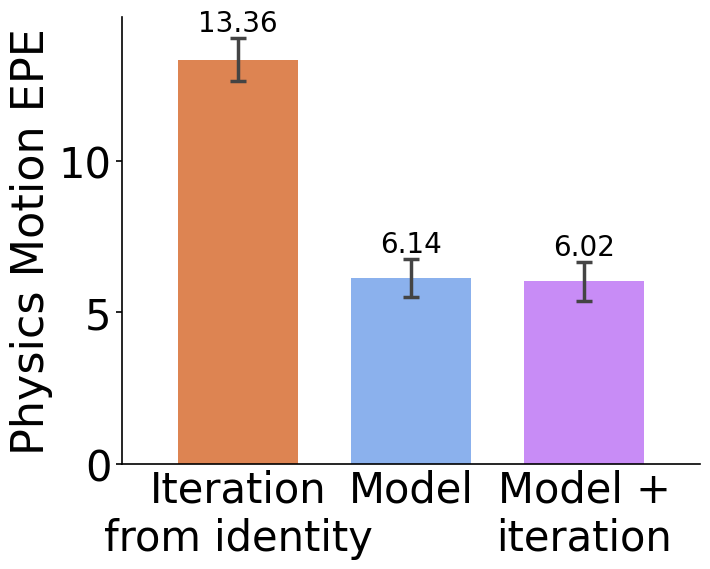

Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model/results/motion_epe_summary_F2013_15846.png


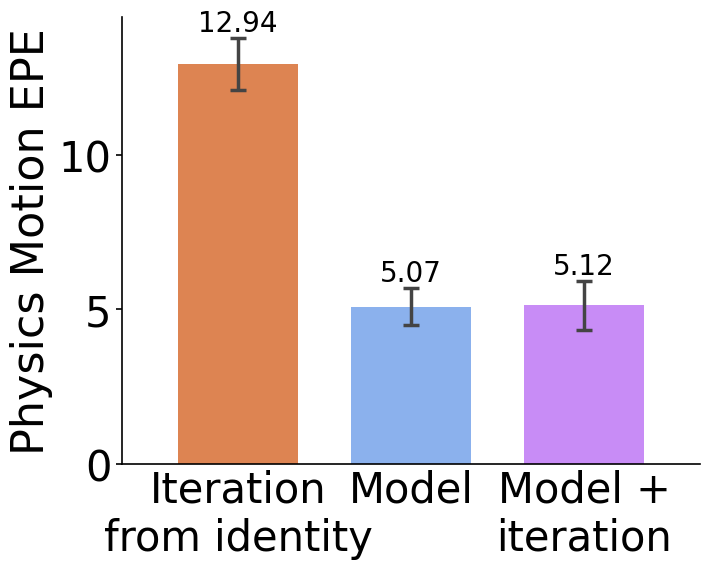

Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model/results/motion_epe_summary_F338_003.png


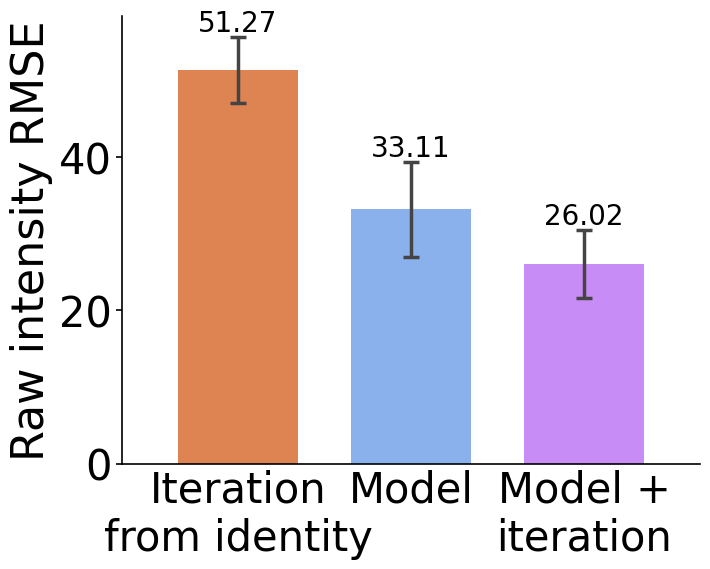

Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model/results/raw_rmse_summary_F2013_15846.png


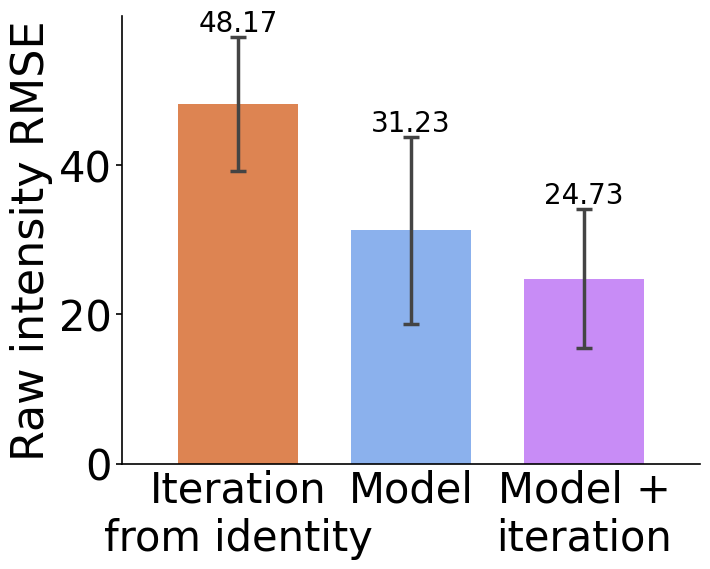

Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model/results/raw_rmse_summary_F338_003.png


In [22]:
METHODS = ["iter_identity", "model", "model_iter"]

# 可选：更好看的显示名称
METHOD_LABELS = {
    "model": "Model",
    "iter_identity": "Iteration\nfrom identity",
    "model_iter": "Model +\niteration",
}

# 柱子颜色（你也可以再换）
METHOD_COLORS = {
    "model": "#8BB1ED",         # 蓝
    "iter_identity": "#DD8452", # 橙
    "model_iter": "#C88CF6",    # 绿
}

rows = []
for npz_path in sorted(OUTPUT_ROOT.rglob("rep*.npz")):
    parts = npz_path.parts
    # Path layout: .../<dataset>/frameXXX/repXX.npz
    dataset = npz_path.parent.parent.name
    frame_idx = int(npz_path.parent.name.replace("frame", ""))
    rep_idx = int(npz_path.stem.replace("rep", ""))
    with np.load(npz_path) as data:
        required_keys = {
            "z_ratio",
            *(
                f"{metric}_{method}"
                for metric in [
                    "epe_3d",
                    "raw_rmse",
                    "epe_phys",
                    "rmse_x",
                    "rmse_y",
                    "rmse_z_voxel",
                    "rmse_z_physical",
                ]
                for method in METHODS
            ),
        }
        missing_keys = required_keys.difference(data.files)
        if missing_keys:
            print(f"Skip incomplete output: {npz_path}; missing {sorted(missing_keys)}")
            continue

        for method in METHODS:
            rows.append({
                "dataset": dataset,
                "frame_idx": frame_idx,
                "rep_idx": rep_idx,
                "method": method,
                "z_ratio": float(data["z_ratio"]),
                "epe_3d": float(data[f"epe_3d_{method}"]),
                "raw_rmse": float(data[f"raw_rmse_{method}"]),
                "epe_phys": float(data[f"epe_phys_{method}"]),
                "rmse_x": float(data[f"rmse_x_{method}"]),
                "rmse_y": float(data[f"rmse_y_{method}"]),
                "rmse_z_voxel": float(data[f"rmse_z_voxel_{method}"]),
                "rmse_z_physical": float(data[f"rmse_z_physical_{method}"]),
            })

csv_path = RESULT_ROOT / "motion_epe_per_case.csv"
if rows:
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    print("Saved:", csv_path)

    # ------------------------------------------------------------
    # 打印 summary
    # ------------------------------------------------------------
    for metric_name in ["epe_phys", "raw_rmse"]:
        print(f"\nSummary: mean +/- std of {metric_name}")
        for dataset in DATASETS:
            for method in METHODS:
                vals = np.array(
                    [r[metric_name] for r in rows if r["dataset"] == dataset and r["method"] == method]
                )
                if len(vals):
                    std = vals.std(ddof=1) if len(vals) > 1 else 0.0
                    print(
                        f"{dataset:12s} {method:14s} n={len(vals):3d} "
                        f"{vals.mean():.5f} +/- {std:.5f}"
                    )

    # ------------------------------------------------------------
    # 统一绘图函数
    # ------------------------------------------------------------
    def plot_metric_by_dataset(
        rows,
        datasets,
        methods,
        metric_key,
        ylabel,
        title_prefix,
        save_prefix,
        log_y=False,
    ):
        for dataset in datasets:
            means = []
            stds = []
            labels = []
            colors = []

            for method in methods:
                vals = np.array(
                    [r[metric_key] for r in rows if r["dataset"] == dataset and r["method"] == method]
                )
                if len(vals):
                    labels.append(METHOD_LABELS.get(method, method))
                    means.append(vals.mean())
                    stds.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)
                    colors.append(METHOD_COLORS.get(method, "#4C72B0"))

            if not means:
                continue

            x = np.arange(len(labels)) * 0.72

            fig, ax = plt.subplots(figsize=(7.2, 5.8))

            bars = ax.bar(
                x,
                means,
                yerr=stds,
                width=0.5,
                color=colors,
                edgecolor="none",
                capsize=6,
                error_kw={
                    "elinewidth": 2.5,
                    "capthick": 2.5,
                    "ecolor": "#444444",
                },
            )
            # 在柱子上方标注均值
            for bar, mean, std in zip(bars, means, stds):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    mean + std + 0.03,                 # 放在误差棒顶端
                    f"{mean:.2f}",              # 保留两位小数
                    ha="center",
                    va="bottom",
                    fontsize=20,
                )
            # 坐标轴标签和标题
            ax.set_xticks(x)
            ax.set_xticklabels(labels, fontsize=30)
            ax.set_ylabel(ylabel, fontsize=32)
            # ax.set_title(f"{title_prefix}: {dataset}", fontsize=22, pad=16)
            if log_y:
                ax.set_yscale("log")
            # 字体放大
            ax.tick_params(axis="y", labelsize=30)
            ax.tick_params(axis="x", length=0)  # 不显示横轴刻度线
            ax.tick_params(axis="y", length=4, width=1.2)

            # 去掉上方和右方框线
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # 左下轴线稍微加粗一点
            ax.spines["left"].set_linewidth(1.2)
            ax.spines["bottom"].set_linewidth(1.2)

            # 不要横向网格线
            ax.grid(False)

            # 两侧留一点空白，让图更舒服
            ax.margins(x=0.12)

            plt.tight_layout()

            fig_path = RESULT_ROOT / f"{save_prefix}_{dataset}.png"
            plt.savefig(fig_path, dpi=300, bbox_inches="tight")
            plt.show()
            print("Saved:", fig_path)

    # ------------------------------------------------------------
    # 分别画 motion EPE
    # ------------------------------------------------------------
    plot_metric_by_dataset(
        rows=rows,
        datasets=DATASETS,
        methods=METHODS,
        metric_key="epe_phys",
        ylabel="Physics Motion EPE",
        title_prefix=None,
        save_prefix="motion_epe_summary",
        log_y=False,
    )

    # ------------------------------------------------------------
    # 分别画 raw intensity RMSE
    # ------------------------------------------------------------
    plot_metric_by_dataset(
        rows=rows,
        datasets=DATASETS,
        methods=METHODS,
        metric_key="raw_rmse",
        ylabel="Raw intensity RMSE",
        title_prefix=None,
        save_prefix="raw_rmse_summary",
    )

else:
    print("No evaluated cases found. Run the simulation and evaluation cells first.")

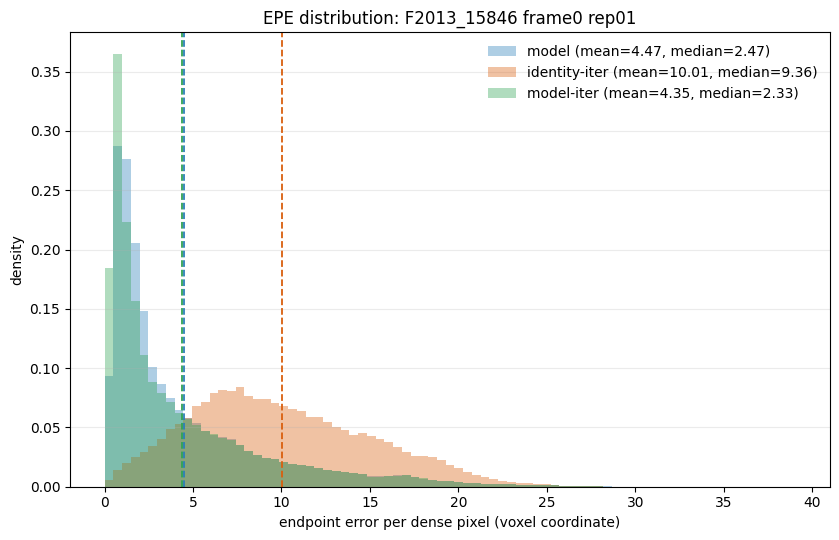

Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.13_large_motion_model/results/epe_hist_example_F2013_frame000_rep01.png
model mean= 4.46989631652832 median= 2.473123073577881 p90= 11.342512130737305 p99= 21.05494499206543
iter_identity mean= 10.010003089904785 median= 9.355941772460938 p90= 17.19532585144043 p99= 22.766782760620117
model_iter mean= 4.350007057189941 median= 2.327451229095459 p90= 11.338729858398438 p99= 21.115554809570312


In [8]:
# Diagnostic: EPE histogram for one selected case
EXAMPLE_NPZ = OUTPUT_ROOT / "F2013_15846" / "frame000" / "rep01.npz"
METHODS = ["model", "iter_identity", "model_iter"]
with np.load(EXAMPLE_NPZ) as data:
    init = data["init_phase_kyx_xyz"]
    gt = data["gt_phase_kyx_xyz"]
    gt_disp = gt - init
    errors = {}
    for method in METHODS:
        pred_disp = data[f"{method}_phase_kyx_xyz"] - init
        err = np.linalg.norm(
            (pred_disp - gt_disp)[:, EVAL_MARGIN:-EVAL_MARGIN, EVAL_MARGIN:-EVAL_MARGIN, :],
            axis=-1,
        ).ravel()
        errors[method] = err

upper = np.max(np.concatenate(list(errors.values())))
bins = np.linspace(0.0, upper, 80)
colors = {"model": "#2c7fb8", "iter_identity": "#d95f0e", "model_iter": "#31a354"}
labels = {"model": "model", "iter_identity": "identity-iter", "model_iter": "model-iter"}
plt.figure(figsize=(8.5, 5.5))
for method in METHODS:
    err = errors[method]
    plt.hist(err, bins=bins, density=True, alpha=0.38, color=colors[method],
             label=f"{labels[method]} (mean={err.mean():.2f}, median={np.median(err):.2f})")
    plt.axvline(err.mean(), color=colors[method], linestyle="--", linewidth=1.3)
plt.xlabel("endpoint error per dense pixel (voxel coordinate)")
plt.ylabel("density")
plt.title("EPE distribution: F2013_15846 frame0 rep01")
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
hist_path = RESULT_ROOT / "epe_hist_example_F2013_frame000_rep01.png"
plt.savefig(hist_path, dpi=200)
plt.show()
print("Saved:", hist_path)
for method in METHODS:
    err = errors[method]
    print(method, "mean=", float(err.mean()), "median=", float(np.median(err)),
          "p90=", float(np.percentile(err, 90)), "p99=", float(np.percentile(err, 99)))
